In [38]:
import pathlib
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib as mpl
import os
import matplotlib.gridspec as gridspec 

In [39]:
def save(fig, path):
    fig.savefig(path, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(str(path).replace(".pdf", ".png"), bbox_inches="tight", pad_inches=0.02)
   # plt.close(fig)

# Figure 1 (Graphical Abstract components)

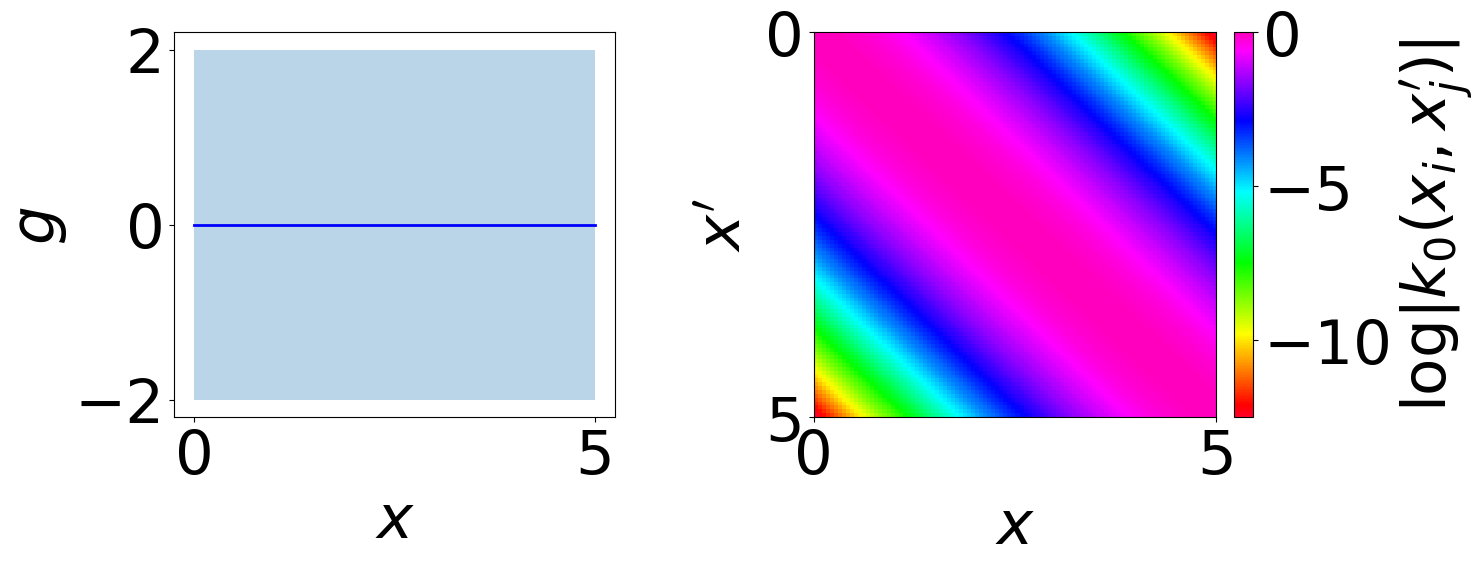

In [59]:
FS = 44
plt.rcParams.update({'font.size': FS})
results = os.path.join("Bessel", "results")
vanilla = np.load(os.path.join(results, "vanilla.npz"))
fig = plt.figure(figsize=(16, 5))
outer = gridspec.GridSpec(1, 2,width_ratios=[1, 1],  wspace=0.45)
left = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=outer[0], hspace=0.05 )
ax = fig.add_subplot(left[0])
x = vanilla["plot_x"]
x0, x1 = float(x[0]), float(x[-1])
ax.plot(x, vanilla["mean"], 'b', linewidth=2)
ax.fill_between(x, vanilla["lower"], vanilla["upper"], alpha=0.3)
ax.set_xticks([x0, x1])
ax.set_xlabel("$x$", fontsize=FS)
ax.set_ylabel(r"""$g$""", fontsize=FS)
ax.tick_params(labelsize=FS)
axK = fig.add_subplot(outer[1])
# extent puts the image in x-coordinates, so the ticks below are x values
# (0 and 5) instead of pixel indices (the 1st and 5th row/column).
im = axK.imshow(
    vanilla["K"],
    cmap="gist_rainbow",
    origin="upper",
    interpolation="none",
    aspect = "auto",
    extent = (x0, x1, x1, x0))

axK.tick_params(
    axis='both',
    which='both',
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom = True,
    labelleft = True,
    labelsize = FS)
axK.set_xticks([x0, x1])
axK.set_yticks([x0, x1])
axK.set_xlabel("$x$", labelpad=8, fontsize=FS)
axK.set_ylabel(r"$x'$", labelpad=8, fontsize=FS)
cbar = fig.colorbar(im, ax=axK, fraction=0.046, pad=0.04)
cbar.set_label(r"$\log |k_0(x_i, x_j')|$", fontsize=FS)
cbar.ax.tick_params(labelsize=FS)
fig.subplots_adjust(right=0.8)

save(fig, os.path.join("graphs", "vanilla.pdf"))


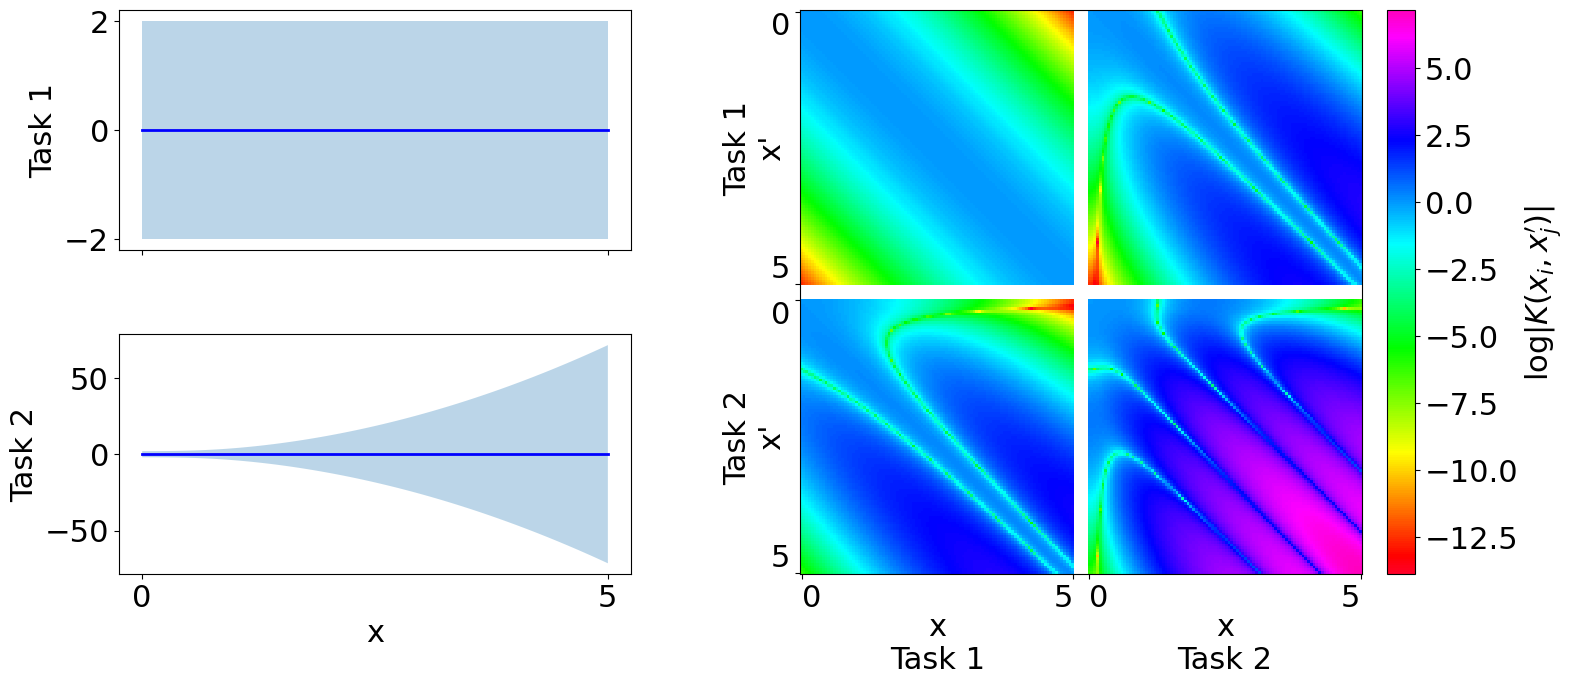

In [52]:
FS = 22
prior = np.load(os.path.join(results, "prior.npz"))
plt.rcParams.update({'font.size': FS})

NTASK, NB, GAP = 2, 100, 5   # tasks, points per task, blank rows separating the blocks

fig = plt.figure(figsize=(16, 6))
outer = gridspec.GridSpec(1, 2,width_ratios=[1, 1.2],  wspace=0.3)
left = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0], hspace=0.35 )

x = prior["plot_x"]
x0, x1 = float(x[0]), float(x[-1])

for i in range(NTASK):
    ax = fig.add_subplot(left[i])
    ax.plot(x, prior["mean"][:,i], 'b', linewidth=2)
    ax.fill_between(x, prior["lower"][:,i], prior["upper"][:,i], alpha=0.3)
    ax.set_xticks([x0, x1])
    ax.tick_params(labelsize=FS)
    if i < NTASK - 1:
        ax.set_xticklabels([])
        ax.set_ylabel("Task 1")
    else:
        ax.set_xlabel("x")
        ax.set_ylabel("Task 2")

axK = fig.add_subplot(outer[1])
im = axK.imshow(
    prior["K"],
    cmap="gist_rainbow",
    origin="upper",
    interpolation="none",
    aspect = "auto")

axK.tick_params(
    axis='both',
    which='both',
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom = True,
    labelleft = True,
    labelsize = FS)

# The blank separator rows keep this image in pixel coordinates, so the ticks are
# placed by hand: task i covers pixels i*(NB+GAP) .. +(NB-1), over which x runs
# from x0 to x1. The two labels on either side of a block boundary are aligned
# towards their own block so they do not sit on top of each other.
ticks = [i * (NB + GAP) + j * (NB - 1) for i in range(NTASK) for j in (0, 1)]
axK.set_xticks(ticks)
axK.set_yticks(ticks)
for j, lab in enumerate(axK.set_xticklabels(["%g" % x0, "%g" % x1] * NTASK)):
    lab.set_ha("left" if j % 2 == 0 else "right")
for j, lab in enumerate(axK.set_yticklabels(["%g" % x0, "%g" % x1] * NTASK)):
    lab.set_va("top" if j % 2 == 0 else "bottom")

# task labels
for i in range(NTASK):
    center = i * (NB + GAP) + (NB - 1) / 2
    axK.annotate("x\nTask %d" % (i + 1),
                 xy=(center, 0), xycoords=("data", "axes fraction"),
                 xytext=(0, -1.25 * FS), textcoords="offset points",
                 ha="center", va="top", ma="center", fontsize=FS)
    axK.annotate("Task %d\nx'" % (i + 1),
                 xy=(0, center), xycoords=("axes fraction", "data"),
                 xytext=(-1.5 * FS, 0), textcoords="offset points",
                 ha="center", va="center", ma="center", rotation=90, fontsize=FS)

fig.subplots_adjust(left=0.05, right=0.86, top=0.97, bottom=0.03)
cbar = fig.colorbar(im, ax=axK, fraction=0.046, pad=0.04)
cbar.set_label(r"$\log |K(x_i, x_j')|$", fontsize=FS)
cbar.ax.tick_params(labelsize=FS)

save(fig, os.path.join("graphs", "prior.pdf"))


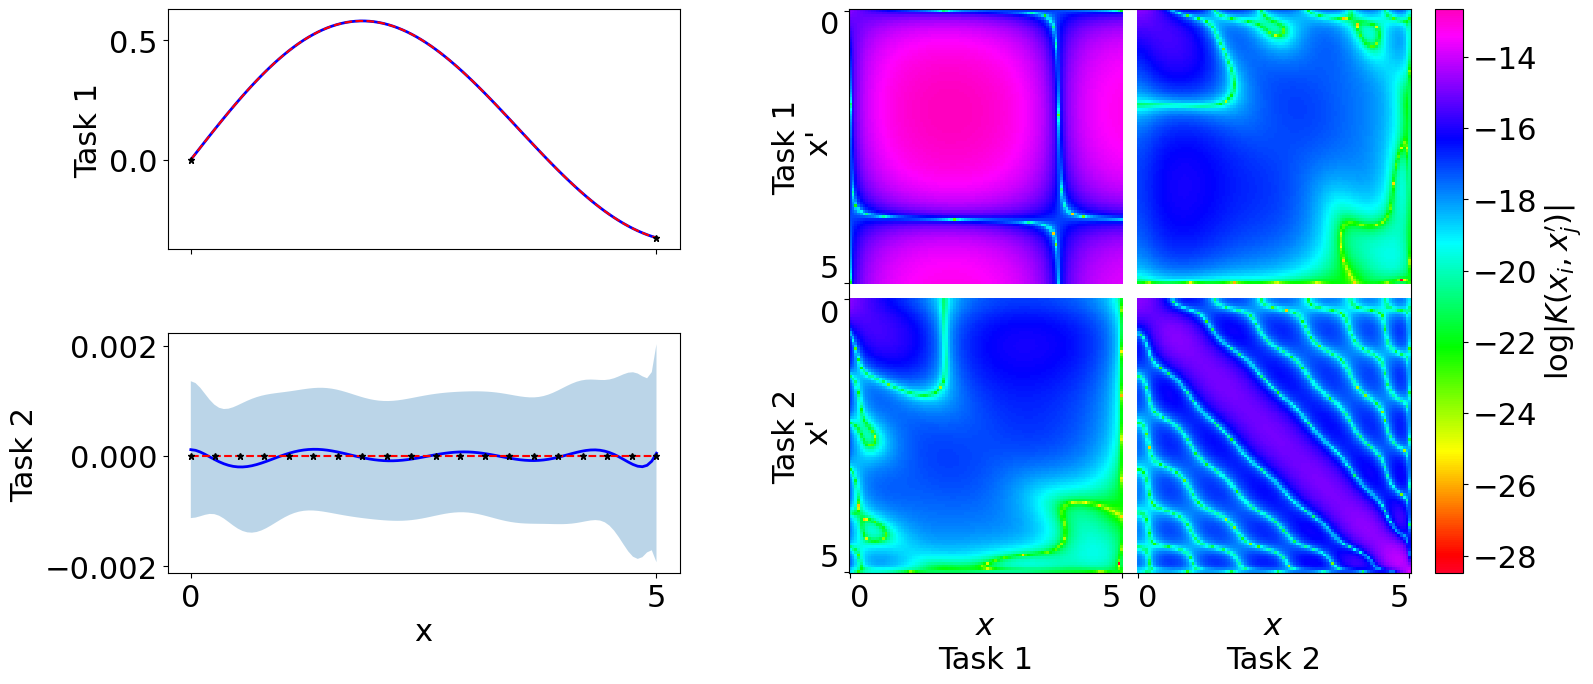

In [54]:
FS = 22
posterior = np.load(os.path.join(results, "posterior.npz"))
plt.rcParams.update({'font.size': FS})

NTASK, NB, GAP = 2, 100, 5   # tasks, points per task, blank rows separating the blocks

fig = plt.figure(figsize=(16, 6))
outer = gridspec.GridSpec(1, 2,width_ratios=[1, 1.2],  wspace=0.3)
left = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0], hspace=0.35 )

x = posterior["plot_x"]
x0, x1 = float(x[0]), float(x[-1])

for i in range(NTASK):
    ax = fig.add_subplot(left[i])
    ax.plot(x, posterior["mean"][:,i], 'b', linewidth=2)
    ax.fill_between(x, posterior["lower"][:,i], posterior["upper"][:,i], alpha=0.3)
    ax.plot(x, posterior["test_y_"+str(i)], "r--")
    ax.plot(posterior["train_x_"+str(i)], posterior["train_y_"+str(i)], "k*", markersize = 5)
    ax.set_xticks([x0, x1])
    ax.tick_params(labelsize=FS)
    if i < NTASK - 1:
        ax.set_xticklabels([])
        ax.set_ylabel("Task 1")
    else:
        ax.set_xlabel("x")
        ax.set_ylabel("Task 2")

axK = fig.add_subplot(outer[1])
im = axK.imshow(
    posterior["K"],
    cmap="gist_rainbow",
    origin="upper",
    interpolation="none",
    aspect = "auto",
)#vmin = -38, vmax = -18)

axK.tick_params(
    axis='both',
    which='both',
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom = True,
    labelleft = True,
    labelsize = FS)

# The blank separator rows keep this image in pixel coordinates, so the ticks are
# placed by hand: task i covers pixels i*(NB+GAP) .. +(NB-1), over which x runs
# from x0 to x1. The two labels on either side of a block boundary are aligned
# towards their own block so they do not sit on top of each other.
ticks = [i * (NB + GAP) + j * (NB - 1) for i in range(NTASK) for j in (0, 1)]
axK.set_xticks(ticks)
axK.set_yticks(ticks)
for j, lab in enumerate(axK.set_xticklabels(["%g" % x0, "%g" % x1] * NTASK)):
    lab.set_ha("left" if j % 2 == 0 else "right")
for j, lab in enumerate(axK.set_yticklabels(["%g" % x0, "%g" % x1] * NTASK)):
    lab.set_va("top" if j % 2 == 0 else "bottom")

# task labels
for i in range(NTASK):
    center = i * (NB + GAP) + (NB - 1) / 2
    axK.annotate("$x$\nTask %d" % (i + 1),
                 xy=(center, 0.), xycoords=("data", "axes fraction"),
                 xytext=(0, -1.25 * FS), textcoords="offset points",
                 ha="center", va="top", ma="center", fontsize=FS)
    axK.annotate("Task %d\n x'" % (i + 1),
                 xy=(0, center), xycoords=("axes fraction", "data"),
                 xytext=(-1.5 * FS, 0), textcoords="offset points",
                 ha="center", va="center", ma="center", rotation=90, fontsize=FS)

fig.subplots_adjust(left=0.05, right=0.86, top=0.97, bottom=0.03)
cbar = fig.colorbar(im, ax=axK, fraction=0.046, pad=0.04, )
cbar.set_label(r"$\log |K(x_i, x_j')|$", fontsize=FS)
cbar.ax.tick_params(labelsize=FS)

save(fig, os.path.join("graphs", "posterior.pdf"))


In [4]:
MM = 1.0 / 25.4
DOUBLE = 183 * MM

COL = {
    "mean": "#1b3a6b",       
    "band": "#9ec3e6",       
    "truth": "#11111a",      
    "coeff": "#c1666b",      
    "coeff_fill": "#e7c6c8",
    "psd": "#2a7f62",        
    "psd_fill": "#cfe6dc",
    "fail": "#b5482f",      
    "fail_fill": "#f0d2c8",
    "accent": "#35472e",
    "accent1": "#BD7F97",
    "accent0": "#3b788a",
    "grid": "#d7d7de",
    "psd0":"#2a7f62",  
    "psd1":"#c1666b"
}


def use_style():
    mpl.rcParams.update({
        "figure.dpi": 200,
        "savefig.dpi": 400,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7.5,
        "axes.titlesize": 8,
        "axes.labelsize": 7.5,
        "axes.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 6.8,
        "ytick.labelsize": 6.8,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.6,
        "ytick.major.size": 2.6,
        "legend.fontsize": 6.6,
        "legend.frameon": False,
        "lines.linewidth": 1.4,
        "lines.solid_capstyle": "round",
        "mathtext.fontset": "dejavusans",
        "axes.titlepad": 4.0,
    })


def panel_label(ax, letter, dx=-0.02, dy=1.04):
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=9,
            fontweight="bold", va="bottom", ha="right")


def thin(ax):
    for s in ax.spines.values():
        s.set_linewidth(0.6)
    ax.tick_params(length=2.6, width=0.6)


In [7]:

CASES = ["Schroedinger_Well", "Diffusion", "Waves"]
names = {"Schroedinger_Well":"Schroedinger Well", "Diffusion":"Diffusion", "Waves":"Wave propagation"}
coeff_label = {"Schroedinger_Well":r"$V(x)$", "Diffusion":r"$\kappa(x)$", "Waves":r"$\frac{\omega^2}{c(x)^2}$"}



def coefficient_panel(ax, x, coeff, letter, name, coeff_label):
    ax.plot(x, coeff, ".", color=COL["mean"], markersize = 2),#, lw=1.0, ls=(0, (4, 2)),
        #    zorder=3, label="reference")
    ax.set_title(name, pad=4)
    #ax.set_ylim([-121, 0])
    ax.set_xlabel("$x$")
    ax.set_ylabel(coeff_label)
    #ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    thin(ax)
    panel_label(ax, letter)
    return ax.get_legend_handles_labels()

def kernel_panel(ax, K, x, letter, name):
   
    x0, x1 = float(x[0]), float(x[-1])
    surf = ax.imshow(K,
            cmap="gist_rainbow",
            origin="upper",
            interpolation="none",
            aspect = "auto",
            extent = (x0, x1, x1, x0))
    ax.set_xticks([x0, x1])
    ax.set_yticks([x0, x1])
    cax = ax.inset_axes([1.04, 0.0, 0.045, 1.0])
    cax.set_in_layout(False)
    cb = plt.colorbar(surf, cax = cax)
    cb.set_label(r"$K(x,x')$", labelpad=2)
    thin(cax)
    ax.set_xlabel("$x$", labelpad=1)
    ax.set_ylabel("$x'$", labelpad=1)
    ax.patch.set_visible(False)
    thin(ax)
    panel_label(ax, letter)

def spectrum_panel(ax, w, letter, type, i):
    idx = np.arange(1, len(w) + 1)
  
    EPS = torch.finfo(type).eps
    U = EPS / 2          # unit roundoff 
    floor = U * np.abs(w).max()
    ax.scatter(idx, abs(w), s=5, color=COL["psd"+str(i)], edgecolor="none", zorder=3)
    ax.set_yscale("log")
    ax.axhline(floor, color=COL["accent"+str(i)], lw=0.8, ls=(0, (2, 2)), zorder=1)
    ax.text(len(w), floor * 1.4, r"noise floor "+str(type), color=COL["accent"+str(i)],#$u\,\lambda_{\max}$"
            va="bottom", ha="right", fontsize=6.0)
    ax.set_xlabel("eigenvalue index")
    ax.set_ylabel(r"eigenvalues of $K(x,x')$")
    thin(ax)
    panel_label(ax, letter)


# Figure 2 (Examples)

In [8]:
use_style()
fig, axes = plt.subplots(3, 3, figsize=(0.9*DOUBLE,  0.7*DOUBLE), sharey = False,
                         gridspec_kw = dict(height_ratios=[1.0, 1.35, 1.0]))
letters = [["a", "b", "c"], ["d", "e", "f"], ["g", "h", "i"]]
handles = labels = None
for j, label in enumerate(CASES):
    data = np.load(label+"/results/result.npz")
    K = data["K"]
    eigvals = data["eigvals"]
    x = data["x"]
    coeff = data["coeff"]
    kernel_panel(axes[1, j], K, x, letters[1][j], None)
    coefficient_panel(axes[0, j], x, coeff, letters[0][j], names[label], coeff_label[label])
    kernel_panel(axes[1, j], K, x, letters[1][j], None)
    axes[1, j].sharex(axes[0, j])  
    axes[1, j].set_xticks([float(x[0]), float(x[-1])])
    spectrum_panel(axes[2, j], eigvals, letters[2][j], torch.float64, 0)

    #show 32 bit result in eigenvalues as well
    data = np.load(label+"/results/result_lp.npz")
    K = data["K"]
    eigvals = data["eigvals"]
    spectrum_panel(axes[2, j], eigvals, letters[2][j], torch.float32, 1)

fig.tight_layout( w_pad=4.0, h_pad=1.8, rect=(0, 0.03, 0.92, 0.99))
fig.canvas.draw()
fig_w, fig_h = fig.get_figwidth(), fig.get_figheight()
for j in range(axes.shape[1]):
    top = axes[0, j].get_position()
    cur = axes[1, j].get_position()
    h = top.width * fig_w / fig_h             
    axes[1, j].set_position([top.x0, cur.y0 + (cur.height - h)/2, top.width, h])


fig.canvas.draw()
rend = fig.canvas.get_renderer()
inv = fig.transFigure.inverted()
centres = []
for i in (0, 2):
    bb = axes[i, 0].yaxis.label.get_window_extent(rend)
    centres.append(inv.transform(((bb.x0 + bb.x1)/2, 0))[0])
x_lab = min(centres)
for i in (0, 2):
    lab = axes[i, 0].yaxis.label
    lab.set_ha("center"); lab.set_va("center")
    pos = axes[i, 0].get_position()
    axes[i, 0].yaxis.set_label_coords(x_lab, pos.y0 + pos.height/2,
                                      transform=fig.transFigure)
pos = axes[1, 0].get_position()
fig.text(x_lab, pos.y0 + pos.height/2, "kernel", rotation=90,
         ha="center", va="center")

for j in range(axes.shape[1]):
    for cax in axes[1, j].child_axes:
        cax.set_in_layout(True)
out = os.path.join("graphs", "figure2.pdf")
save(fig, out)
print("wrote", out)

wrote graphs/figure2.pdf


# Figure 3 (Appendix)

In [9]:

def spectrum_panel_figure3(ax, w, letter, i, l,):
    idx = np.arange(1, len(w) + 1)
    EPS = torch.finfo(torch.float64).eps
    U = EPS / 2          # unit roundoff 
    floor = U * np.abs(w).max()
    ax.plot(idx, abs(w), "o", markersize=.5, color = (0.2*i, 0, 1-0.2*i),  label = "%.1f"%l)#, color=COL["psd"], edgecolor="none", zorder=3)
    ax.set_yscale("log")
    ax.axhline(floor, color = (0.2*i, 0, 1-0.2*i), lw=0.8, ls=(0, (2, 2)), zorder=1, label = "_notshown")
    thin(ax)
    panel_label(ax, letter)
    return floor, w

use_style()
fig, axes = plt.subplots(1, 3, figsize=(0.9*DOUBLE,  0.3*DOUBLE), sharey = False,)
letters = [["a", "b", "c"]]
handles = labels = None
for j, label in enumerate(CASES):
    old_floor = 0
    floors = []
    ll = [0.1, 0.5, 1., 3, 10]
    shape = {"l":"o", "A":"^"}
    for i in range(5):
        l = ll[i]
        for a in ["l"]:
            data = np.load(label+"/results/result_"+a+"%.1f.npz"%l)
            K = data["K"]
            eigvals = data["eigvals"]
            x = data["x"]
            coeff = data["coeff"]
            
            axes[j].sharex(axes[j]) 
            floor, w = spectrum_panel_figure3(axes[j], eigvals, letters[0][j], i, l)
            floors.append(floor)
            if old_floor<floor:
                old_floor = floor
                ww = w
    floor = max(floors)
    axes[j].set_title(names[label])
    axes[j].text(len(ww), floor * 1.4, r"noise floor $u\,\lambda_{\max}$", color=COL["accent"],
                va="bottom", ha="right", fontsize=6.0)
    axes[j].set_xlabel("eigenvalue index")
    axes[j].set_ylabel(r"eigenvalues of $K(x, x')$")
    axes[-1].legend( loc=(0.3, 0.7),title = "lengthscale", ncols = 3, frameon = True, borderpad = 0.2, handlelength = 0.1, labelspacing = 0., columnspacing = 0.3 )
fig.tight_layout( w_pad=4.0, h_pad=1.8, rect=(0, 0.03, 0.92, 0.99))

# tight_layout sizes each panel from its own decorations, so the kernel panels
# end up narrower than the coefficient panels above them.  Pin them afterwards:
# identical x0 and width as row 0, and a height that makes the box square in
# inches.  The colorbar insets follow their parents automatically.



out = os.path.join("graphs", "figure3.pdf")
save(fig, out)
print("wrote", out)



/tmp/ipykernel_7023/2906453610.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend( loc=(0.3, 0.7),title = "lengthscale", ncols = 3, frameon = True, borderpad = 0.2, handlelength = 0.1, labelspacing = 0., columnspacing = 0.3 )


wrote graphs/figure3.pdf
